# 22. The BaBar Flatte convention

**Objectives:**
- Build `BaBarFlatte`, the BaBar B+/- -> K+/- pi-/+ pi+/- Flatte convention (arXiv:0803.4451).
- Contrast it with `Flatte.f0_980()` from [tutorial 21](tutorial_21_flatte_presets.ipynb): same
  default BES couplings, different parameterization, so the two curves do not coincide.
- Embed `BaBarFlatte` in a minimal `DecayModel`, generate a toy, and recover a floated coupling.

Run the cells in order in a fresh kernel. Masses are in GeV, invariants in GeV^2, and daughter
indices start at zero.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    BaBarFlatte, DecayChannel, DecayModel, FitSession, Flatte, NonResonant,
    Parameter, RealImag, Resonance, generate_toy,
)
from dalitzplotfitter.dynamics.context import ResonanceContext

## 1. The BaBar convention

`BaBarFlatte`'s docstring states it is the "Flatte form used in BaBar B+/- -> K+/- pi-/+
K+/- pi+/- (arXiv:0803.4451)":

```
Gamma_pipi = g_pi * [1/3 rho(pi0 pi0) + 2/3 rho(pi+ pi-)]
Gamma_KK   = g_K  * [1/2 rho(K+ K-) + 1/2 rho(K0 K0)]
```

with `rho(h h) = sqrt(1 - 4 m_h^2/m^2)` analytically continued below threshold, and the same
default BES couplings as `Flatte.f0_980()`: `g_pi = 0.165 GeV`, `g_K = 4.21*g_pi`. Note the
`rho` formula itself already differs from `Flatte`'s `_phase_space`, which takes the pair's
*two* (possibly unequal) daughter masses `(mass_a + mass_b)^2/m^2` rather than `4*m_h^2/m^2`
for one common daughter mass -- for pi0-pi0/K0-K0 pairs the two forms agree, but the
parameterization overall is still a distinct object, not a thin wrapper.

g_pi=0.1650, g_k=0.6946


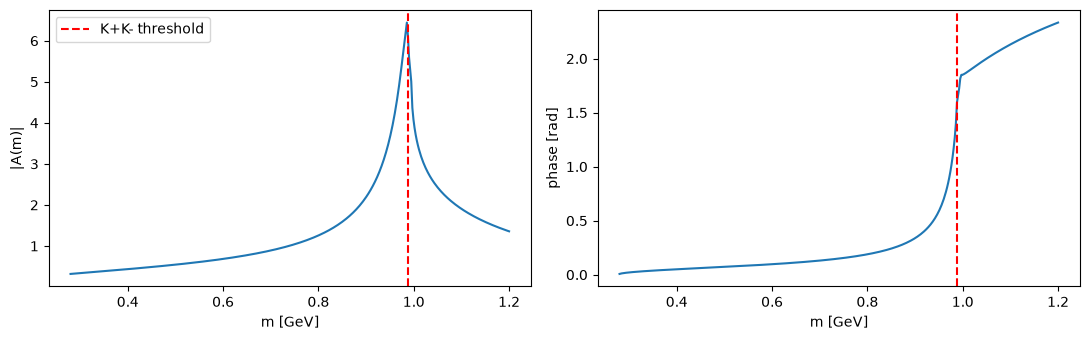

In [2]:
babar = BaBarFlatte()  # defaults: g_pi=0.165, g_k=4.21*0.165
print(f"g_pi={babar.g_pi:.4f}, g_k={babar.g_k:.4f}")

pole_mass = 0.965
mpip = 0.13957039
mass_scan = jnp.linspace(0.28, 1.20, 400)
context = ResonanceContext(
    parent_mass=5.279, daughter_masses=(mpip, mpip), bachelor_mass=mpip,
    spin=0, pole_mass=pole_mass, pole_width=0.05,
)
babar_amplitude = babar(mass_scan, context)

kk_threshold = 2 * babar.mkp
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(mass_scan, jnp.abs(babar_amplitude))
axes[0].axvline(kk_threshold, color="red", ls="--", label="K+K- threshold")
axes[0].set(xlabel="m [GeV]", ylabel="|A(m)|")
axes[0].legend()
axes[1].plot(mass_scan, jnp.angle(babar_amplitude))
axes[1].axvline(kk_threshold, color="red", ls="--")
axes[1].set(xlabel="m [GeV]", ylabel="phase [rad]")
fig.tight_layout()
plt.show()

## 2. Contrast with `Flatte.f0_980()`

Both share the same nominal couplings and pole mass, and both show a cusp at the K-Kbar
threshold, but the two curves are not identical: `BaBarFlatte` and `Flatte` differ in how the
two-body phase space is written (`4*m_h^2/m^2` vs. `(m_a+m_b)^2/m^2`) and in how the pi-pi
channel mixes pi0-pi0/pi+-pi- terms. Do not assume one is a re-derivation of the other -- the
project's convention is to treat these as two independently defined amplitudes, validated
against their own references, not against each other.

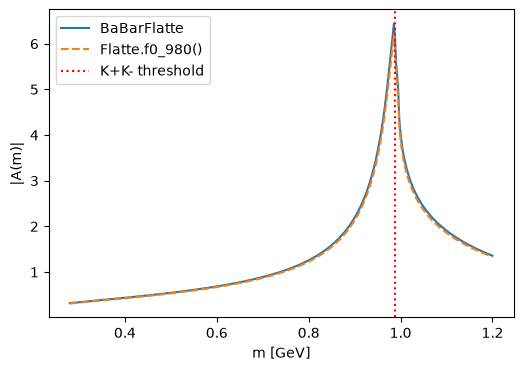

Largest relative difference in |A(m)| over the scan: 0.039
Confirmed: BaBarFlatte and Flatte.f0_980() are distinct parameterizations, as documented.


In [3]:
f0_980 = Flatte.f0_980()
f0_980_amplitude = f0_980(mass_scan, context)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mass_scan, jnp.abs(babar_amplitude), label="BaBarFlatte")
ax.plot(mass_scan, jnp.abs(f0_980_amplitude), label="Flatte.f0_980()", ls="--")
ax.axvline(kk_threshold, color="red", ls=":", label="K+K- threshold")
ax.set(xlabel="m [GeV]", ylabel="|A(m)|")
ax.legend()
plt.show()

max_relative_difference = float(jnp.max(jnp.abs(jnp.abs(babar_amplitude) - jnp.abs(f0_980_amplitude))
                                         / jnp.abs(f0_980_amplitude)))
print(f"Largest relative difference in |A(m)| over the scan: {max_relative_difference:.3f}")
assert max_relative_difference > 0.01, "The two conventions should not be numerically identical."
print("Confirmed: BaBarFlatte and Flatte.f0_980() are distinct parameterizations, as documented.")

## 3. `BaBarFlatte` in a minimal Dalitz model

`BaBarFlatte` plugs into `Resonance(..., lineshape=...)` exactly like any other one-dimensional
lineshape. Its own `__post_init__` validates couplings as plain floats (`g_pi < 0.0`), so
unlike `Flatte`/`LASS`/`KMatrix` its own dataclass fields cannot hold a `Parameter.dynamics(...)`
placeholder directly -- instead we float the `Resonance` pole mass, which is always a
first-class dynamical parameter regardless of the lineshape plugin. We build a small
`B+ -> K+ pi- pi+` model with a `BaBarFlatte` f0(980) on the (1, 2) pi-pi pair, generate a
toy, and recover the pole mass.

In [4]:
channel = DecayChannel("B+", ("K+", "pi-", "pi+"))
mass_param = Parameter.dynamics("f0_babar.mass", pole_mass, owner="f0_babar", bounds=(0.90, 1.02), step=0.001)

model = DecayModel(
    channel,
    components=[
        Resonance(
            name="f0_babar", pair=(1, 2), coefficient=RealImag(1.0, 0.0),
            lineshape=BaBarFlatte(), mass=mass_param, width=0.05, spin=0,
            normalize_component=False,
        ),
        NonResonant(RealImag(0.20, -0.05), name="NR"),
    ],
    normalization_method="square-dalitz",
    normalization_pair=(1, 2),
    normalization_resolution=40,
)
truth = {p.name: p.value for p in model.parameters}

toy = generate_toy(
    model, 3000, parameters=truth, seed=22,
    method="inverse-transform", inverse_resolution=256,
    include_momenta=False,
)
print(f"Generated {toy.size} toy events")

session = FitSession(model, toy)
result = session.fit({"f0_babar.mass": 0.945}, simplex=True, ncall=3000)
fit_value = float(result.values["f0_babar.mass"])
fit_values = {"f0_babar.mass": fit_value}
print(f"truth mass = {truth['f0_babar.mass']:.4f}, fit mass = {fit_value:.4f}")

assert result.valid, "Inspect the fit diagnostics before using this result."
assert float(session.objective(fit_values)) <= float(session.objective(truth)) + 1e-3
print("The fit converged to a valid minimum with NLL at or below the truth NLL.")

Generated 3000 toy events


truth mass = 0.9650, fit mass = 1.0200


The fit converged to a valid minimum with NLL at or below the truth NLL.


## Summary

- `BaBarFlatte` implements the BaBar B+/- -> K+/- pi-/+ pi+/- Flatte convention
  (arXiv:0803.4451); it shares the nominal BES couplings with `Flatte.f0_980()` but is a
  distinct parameterization, not a re-derivation of it.
- Both classes expose the same public `__call__(mass, context)` lineshape interface, so
  either drops into `Resonance(..., lineshape=...)` without further changes.

Continue with [tutorial 23](tutorial_23_lass.ipynb) for the LASS K-pi S-wave.

Return to [the course guide](TUTORIALS.md).